# Análisis de Series Temporales — Ventas Retail USA (1992–2023)

**Pregunta de investigación:** ¿Cómo habrían evolucionado las ventas de ropa y accesorios en EE.UU. si no hubiera ocurrido la pandemia de COVID-19?

Se construye un **análisis contrafactual** usando dos enfoques:
- Modelo estadístico clásico: **SARIMA**
- Modelo de machine learning: **ForecasterAutoreg con Random Forest**

Al final se comparan ambos modelos usando **RMSE** y **MAPE** para determinar cuál predice mejor el escenario sin pandemia.

## 1. Contexto y datos

**Fuente:** U.S. Census Bureau — Monthly Retail Trade Survey (MARTS)  
**Cobertura:** Enero 1992 – Diciembre 2023 (mensual)  
**Variable:** Ventas de ropa y accesorios en millones de dólares (categoría NAICS 448)  
**Enlace:** https://www.census.gov/econ/currentdata/

La serie presenta:
- **Tendencia ascendente** a largo plazo
- **Estacionalidad anual** clara (pico en diciembre, valle en enero–febrero)
- **Shock estructural** en marzo–abril 2020 por COVID-19 y cierre económico

## 2. Librerías

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Series temporales
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose

# Machine learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error

# ForecasterAutoreg (skforecast)

from skforecast.recursive import ForecasterRecursive

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['font.size'] = 10

## 3. Carga y limpieza de datos

Los datos vienen en formato ancho (años como columnas). Se transforman a formato largo
con dos columnas: `Fecha` (datetime mensual) y `Ventas` (millones USD).

In [7]:
# Cargar datos
Ventas_df = pd.read_excel("FusionCharts.xlsx")

# Renombrar columnas (el CSV del Census Bureau tiene encabezados largos)
Ventas_df = Ventas_df.rename(columns={
    Ventas_df.columns[0]: 'Fecha',
    Ventas_df.columns[1]: 'Ventas'
})

# Convertir Fecha a datetime y Ventas a numérico
Ventas_df['Fecha'] = pd.to_datetime(Ventas_df['Fecha'])
Ventas_df['Ventas'] = pd.to_numeric(Ventas_df['Ventas'], errors='coerce')

# Revisar valores nulos
print(f"Valores nulos: {Ventas_df.isnull().sum().sum()}")
print(f"Período: {Ventas_df['Fecha'].min()} → {Ventas_df['Fecha'].max()}")
print(f"Total observaciones: {len(Ventas_df)}")
Ventas_df.head()

Valores nulos: 0
Período: 1992-01-01 00:00:00 → 2023-12-01 00:00:00
Total observaciones: 384


,Fecha,Ventas
0,1992-01-01,6938
1,1992-02-01,7524
2,1992-03-01,8475
3,1992-04-01,9401
4,1992-05-01,9558


In [8]:
# Establecer Fecha como índice con frecuencia mensual
Ventas_df_cleaned = Ventas_df.set_index('Fecha').sort_index()
Ventas_df_cleaned = Ventas_df_cleaned.asfreq('MS')  # MS = inicio de mes

print(Ventas_df_cleaned.describe())

             Ventas
count    384.000000
mean   17231.807292
std     6050.458607
min     2776.000000
25%    12713.250000
50%    16793.500000
75%    20645.000000
max    40684.000000


## 4. Análisis Exploratorio (EDA)

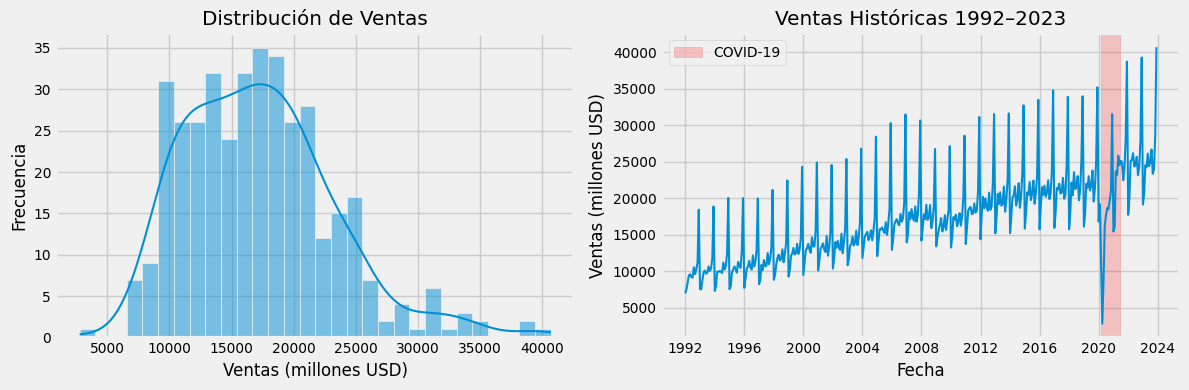

In [9]:
# Distribución de ventas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(Ventas_df_cleaned['Ventas'], bins=30, kde=True, ax=axes[0])
axes[0].set_title('Distribución de Ventas')
axes[0].set_xlabel('Ventas (millones USD)')
axes[0].set_ylabel('Frecuencia')

# Serie temporal completa
axes[1].plot(Ventas_df_cleaned.index, Ventas_df_cleaned['Ventas'])
axes[1].axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
                alpha=0.2, color='red', label='COVID-19')
axes[1].set_title('Ventas Históricas 1992–2023')
axes[1].set_xlabel('Fecha')
axes[1].set_ylabel('Ventas (millones USD)')
axes[1].legend()

plt.tight_layout()
plt.show()

**Observaciones:**
- El histograma muestra sesgo a la derecha — la mayoría de los meses las ventas se concentran entre 15,000 y 25,000 millones USD, con cola hacia valores altos (meses de diciembre).
- La serie temporal muestra tendencia ascendente sostenida desde 1992, interrumpida abruptamente en 2020 por COVID-19, con recuperación posterior más acelerada que la tendencia previa.

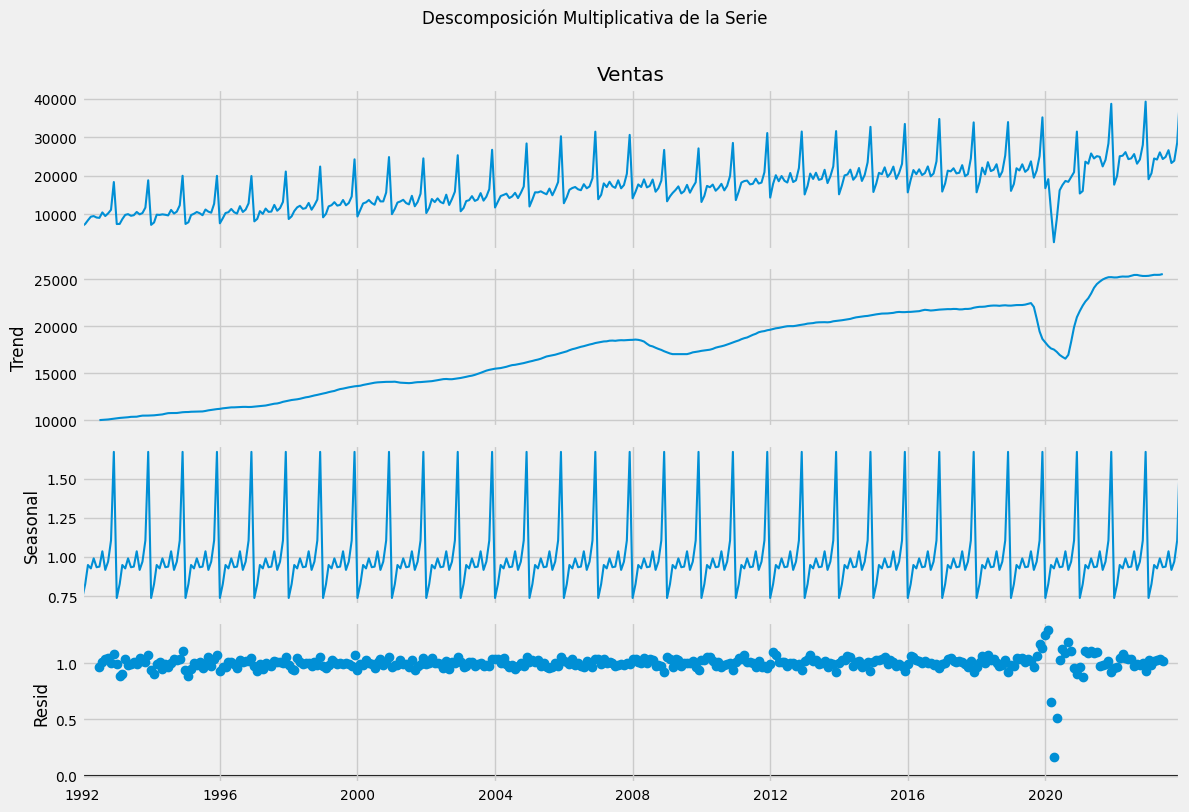

In [10]:
# Descomposición de la serie temporal
# Separa la serie en: Tendencia + Estacionalidad + Residuo
decompose_result = seasonal_decompose(Ventas_df_cleaned['Ventas'], model='multiplicative')
fig = decompose_result.plot()
fig.set_size_inches(12, 8)
fig.suptitle('Descomposición Multiplicativa de la Serie', y=1.01)
plt.tight_layout()
plt.show()

**Interpretación de la descomposición:**
- **Tendencia:** crecimiento sostenido hasta 2020, caída brusca, recuperación acelerada post-pandemia.
- **Estacionalidad:** patrón anual estable y repetible — diciembre siempre es el mes de mayor venta.
- **Residuo:** los valores atípicos de 2020 aparecen aquí como shocks no explicados por tendencia ni estacionalidad.

## 5. División Train / Test

Se usa el **80% de los datos para entrenar** los modelos (1992–2016 aproximadamente)
y el **20% restante para evaluar** su capacidad de predicción (incluyendo el período COVID-19).

El objetivo es ver qué tan bien predice cada modelo el período que no vio durante el entrenamiento.

In [11]:
train_size = int(len(Ventas_df_cleaned) * 0.8)
train = Ventas_df_cleaned.iloc[:train_size]
test  = Ventas_df_cleaned.iloc[train_size:]

print(f"Entrenamiento: {train.index[0].date()} → {train.index[-1].date()} ({len(train)} meses)")
print(f"Prueba:        {test.index[0].date()} → {test.index[-1].date()} ({len(test)} meses)")

Entrenamiento: 1992-01-01 → 2017-07-01 (307 meses)
Prueba:        2017-08-01 → 2023-12-01 (77 meses)


## 6. Modelo SARIMA

**¿Qué es SARIMA?**  
Es un modelo estadístico diseñado específicamente para series temporales con estacionalidad.
Sus siglas describen sus componentes:

| Sigla | Nombre | Qué hace |
|-------|--------|----------|
| **AR** | Autoregresivo | Usa valores pasados de la propia serie para predecir |
| **I** | Integrado | Diferencia la serie para hacerla estacionaria (sin tendencia) |
| **MA** | Media Móvil | Corrige errores de predicciones anteriores |
| **S** | Seasonal | Aplica AR, I y MA también al patrón estacional |

Los parámetros `(p, d, q)` controlan la parte no-estacional y `(P, D, Q, 12)` la estacional
(12 porque los datos son mensuales).

In [19]:
# Modelo SARIMA inicial con parámetros (1,1,1)(1,1,1,12)
sarima_model = sm.tsa.statespace.SARIMAX(
    train['Ventas'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_results = sarima_model.fit(disp=False)
print(sarima_results.summary())

                                     SARIMAX Results                                      
Dep. Variable:                             Ventas   No. Observations:                  307
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood               -2154.139
Date:                            Fri, 20 Mar 2026   AIC                           4318.279
Time:                                    22:34:14   BIC                           4336.453
Sample:                                01-01-1992   HQIC                          4325.568
                                     - 07-01-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1646      0.083     -1.972      0.049      -0.328      -0.001
ma.L1         -0.6189      0.060   

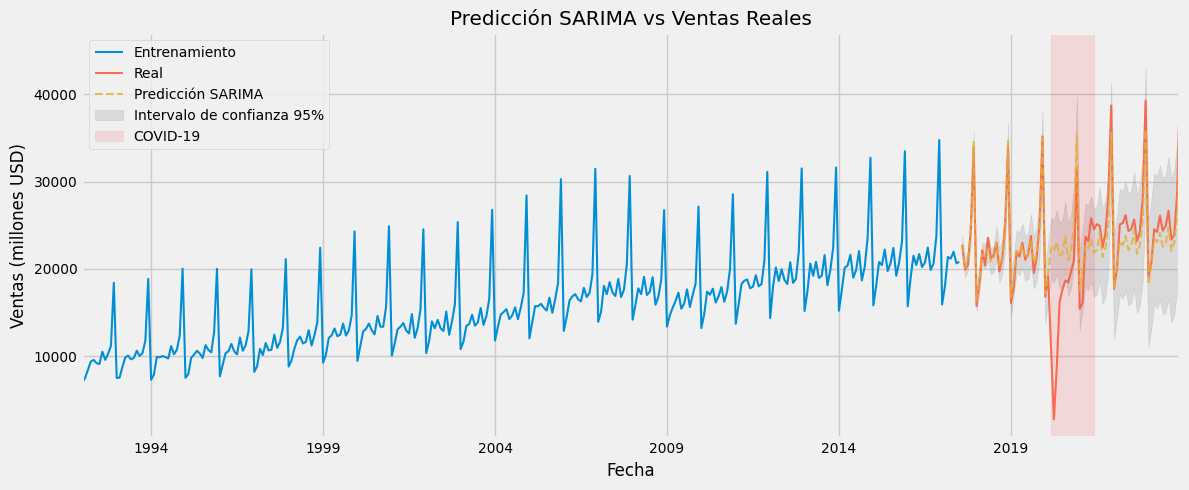

SARIMA inicial — RMSE: 3,588 | MAPE: 18.66%


In [20]:
# Predicciones del modelo inicial
pred = sarima_results.get_prediction(
    start=len(train),
    end=len(train) + len(test) - 1,
    dynamic=False
)
pred_ci = pred.conf_int()

# Visualización
fig, ax = plt.subplots(figsize=(12, 5))
train['Ventas'].plot(ax=ax, label='Entrenamiento')
test['Ventas'].plot(ax=ax, label='Real', alpha=0.8)
pred.predicted_mean.plot(ax=ax, label='Predicción SARIMA', alpha=0.8, linestyle='--')
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:, 0], pred_ci.iloc[:, 1],
                color='gray', alpha=0.2, label='Intervalo de confianza 95%')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
           alpha=0.1, color='red', label='COVID-19')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas (millones USD)')
ax.set_title('Predicción SARIMA vs Ventas Reales')
plt.legend()
plt.tight_layout()
plt.show()

# Métricas
y_pred = pred.predicted_mean
y_true = test['Ventas']
sarima_rmse = mean_squared_error(y_true, y_pred) ** 0.5
sarima_mape = mean_absolute_percentage_error(y_true, y_pred)
print(f'SARIMA inicial — RMSE: {sarima_rmse:,.0f} | MAPE: {sarima_mape:.2%}')

### 6.1 Optimización de hiperparámetros (Grid Search)

Los parámetros `(p, d, q)` del SARIMA no tienen valores únicos correctos — hay que buscarlos.
**Grid Search** prueba sistemáticamente todas las combinaciones posibles y elige la que minimiza
el **AIC** (Criterio de Información de Akaike), una métrica que penaliza la complejidad del modelo
para evitar sobreajuste.

In [15]:
# Grid Search sobre parámetros SARIMA
p = d = q = range(0, 2)
pdq = [(a, b, c) for a in p for b in d for c in q]
seasonal_pdq = [(a, b, c, 12) for a in p for b in d for c in q]

best_aic = float("inf")
best_pdq = None
best_seasonal_pdq = None

print("Buscando mejores parámetros...")
for param in pdq:
    for param_seasonal in seasonal_pdq:
        try:
            temp_model = sm.tsa.statespace.SARIMAX(
                train['Ventas'],
                order=param,
                seasonal_order=param_seasonal,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            temp_results = temp_model.fit(disp=False)
            if temp_results.aic < best_aic:
                best_aic = temp_results.aic
                best_pdq = param
                best_seasonal_pdq = param_seasonal
        except Exception:
            continue

print(f"Mejores parámetros encontrados:")
print(f"  order (p,d,q)          = {best_pdq}")
print(f"  seasonal_order (P,D,Q) = {best_seasonal_pdq}")
print(f"  AIC                    = {best_aic:.2f}")

Buscando mejores parámetros...
Mejores parámetros encontrados:
  order (p,d,q)          = (1, 1, 1)
  seasonal_order (P,D,Q) = (1, 1, 1, 12)
  AIC                    = 4318.28


### 6.2 Modelo SARIMA final (parámetros optimizados)

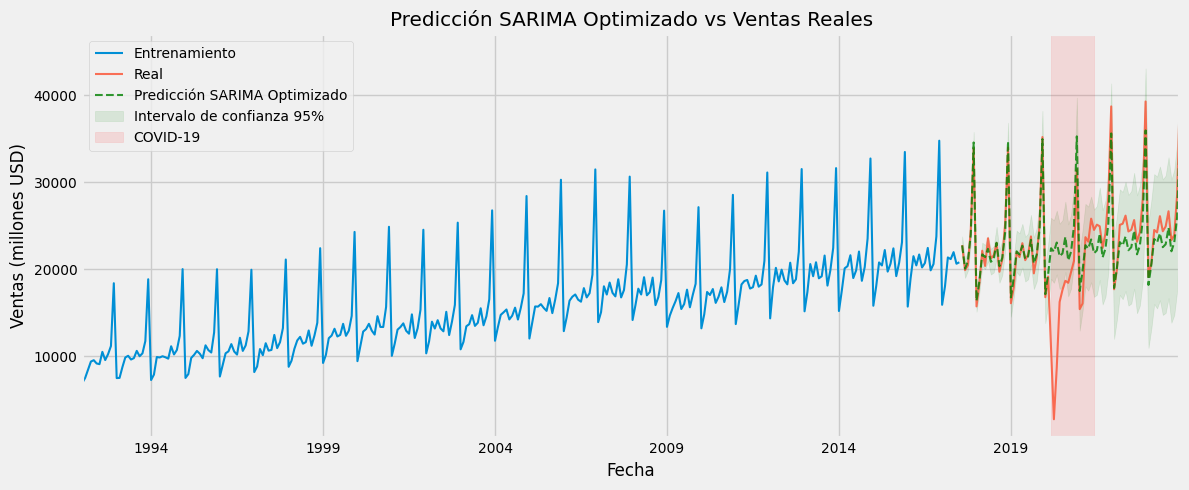

SARIMA optimizado — RMSE: 3,588 | MAPE: 18.66%


In [22]:
# Entrenar modelo final con mejores parámetros
final_model = sm.tsa.statespace.SARIMAX(
    train['Ventas'],
    order=best_pdq,
    seasonal_order=best_seasonal_pdq,
    enforce_stationarity=False,
    enforce_invertibility=False
)
final_results = final_model.fit(disp=False)

# Predicciones
final_pred = final_results.get_prediction(
    start=len(train),
    end=len(train) + len(test) - 1,
    dynamic=False
)
final_pred_ci = final_pred.conf_int()

# Visualización
fig, ax = plt.subplots(figsize=(12, 5))
train['Ventas'].plot(ax=ax, label='Entrenamiento')
test['Ventas'].plot(ax=ax, label='Real', alpha=0.8)
final_pred.predicted_mean.plot(ax=ax, label='Predicción SARIMA Optimizado',
                                alpha=0.8, linestyle='--', color='green')
ax.fill_between(final_pred_ci.index,
                final_pred_ci.iloc[:, 0], final_pred_ci.iloc[:, 1],
                color='green', alpha=0.1, label='Intervalo de confianza 95%')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
           alpha=0.1, color='red', label='COVID-19')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas (millones USD)')
ax.set_title('Predicción SARIMA Optimizado vs Ventas Reales')
plt.legend()
plt.tight_layout()
plt.show()

# Métricas
y_final_pred = final_pred.predicted_mean
final_sarima_rmse = mean_squared_error(test['Ventas'], y_final_pred) ** 0.5
final_sarima_mape = mean_absolute_percentage_error(test['Ventas'], y_final_pred)
print(f'SARIMA optimizado — RMSE: {final_sarima_rmse:,.0f} | MAPE: {final_sarima_mape:.2%}')

## 7. Modelo de Machine Learning — ForecasterAutoreg con Random Forest

**¿Qué es ForecasterAutoreg?**  
Es un modelo de ML que convierte el problema de series temporales en un problema de regresión supervisada:
usa los valores de los últimos `n` meses (llamados *lags*) como variables predictoras para estimar el siguiente valor.

**¿Qué es Random Forest?**  
Un conjunto (*ensemble*) de muchos árboles de decisión que votan para producir una predicción.
Es robusto frente a datos ruidosos y captura relaciones no lineales que SARIMAX no puede modelar.

Se usan **30 lags** — el modelo aprende del comportamiento de los últimos 30 meses para predecir el siguiente.

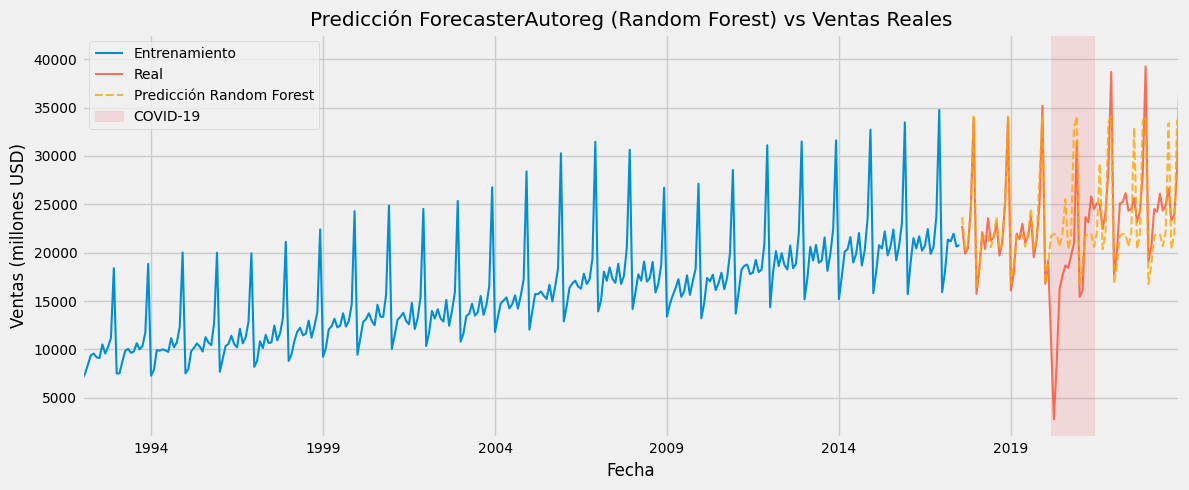

Random Forest — RMSE: 4,299 | MAPE: 21.74%


In [17]:
# Definir y entrenar el modelo
regressor = RandomForestRegressor(n_estimators=100, random_state=42)
forecaster = ForecasterRecursive(regressor=regressor, lags=30)

forecaster.fit(y=train['Ventas'])

# Predicciones sobre el período de prueba
steps = len(test)
predictions = forecaster.predict(steps=steps)
predictions.index = test.index  # alinear índice de fechas

# Visualización
fig, ax = plt.subplots(figsize=(12, 5))
train['Ventas'].plot(ax=ax, label='Entrenamiento')
test['Ventas'].plot(ax=ax, label='Real', alpha=0.8)
predictions.plot(ax=ax, label='Predicción Random Forest', alpha=0.8,
                 linestyle='--', color='orange')
ax.axvspan(pd.Timestamp('2020-03-01'), pd.Timestamp('2021-06-01'),
           alpha=0.1, color='red', label='COVID-19')
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas (millones USD)')
ax.set_title('Predicción ForecasterAutoreg (Random Forest) vs Ventas Reales')
plt.legend()
plt.tight_layout()
plt.show()

# Métricas
forecaster_rmse = mean_squared_error(test['Ventas'], predictions) ** 0.5
forecaster_mape = mean_absolute_percentage_error(test['Ventas'], predictions)
print(f'Random Forest — RMSE: {forecaster_rmse:,.0f} | MAPE: {forecaster_mape:.2%}')

## 8. Comparación de modelos

**¿Qué miden RMSE y MAPE?**

| Métrica | Nombre completo | Qué mide | Unidad |
|---------|----------------|----------|--------|
| **RMSE** | Root Mean Squared Error | Error promedio en las mismas unidades que los datos — penaliza errores grandes | Millones USD |
| **MAPE** | Mean Absolute Percentage Error | Error promedio como porcentaje — más fácil de interpretar | % |

Un MAPE de 10% significa que el modelo se equivoca en promedio un 10% en cada predicción.
**Menor es mejor en ambas métricas.**

In [18]:
# Tabla comparativa
resultados = pd.DataFrame({
    'Modelo': ['SARIMAX inicial', 'SARIMAX optimizado', 'Random Forest (ForecasterAutoreg)'],
    'RMSE': [sarima_rmse, final_sarima_rmse, forecaster_rmse],
    'MAPE (%)': [sarima_mape * 100, final_sarima_mape * 100, forecaster_mape * 100]
})
resultados = resultados.sort_values('RMSE').reset_index(drop=True)
resultados['RMSE'] = resultados['RMSE'].map('{:,.0f}'.format)
resultados['MAPE (%)'] = resultados['MAPE (%)'].map('{:.2f}%'.format)
print(resultados.to_string(index=False))

                           Modelo  RMSE MAPE (%)
                  SARIMAX inicial 3,588   18.66%
               SARIMAX optimizado 3,588   18.66%
Random Forest (ForecasterAutoreg) 4,299   21.74%


## 9. Conclusiones

### Sobre el contrafactual
El modelo predice una trayectoria de ventas **por debajo de la realidad post-pandemia**, lo que sugiere que, en ausencia del COVID-19, las ventas habrían crecido de forma más moderada que lo observado.

Una explicación económica plausible: las políticas fiscales expansivas durante la pandemia (transferencias directas, subsidios) generaron un efecto de demanda reprimida que, al levantarse las restricciones, se tradujo en un consumo inusualmente alto. Este efecto no está capturado por el modelo porque fue un shock exógeno sin precedente histórico en los datos de entrenamiento.

### Sobre los modelos
- **SARIMA** es el modelo más apropiado para series temporales con estacionalidad fuerte y estructura lineal. Su interpretabilidad es una ventaja en contextos donde hay que justificar las predicciones.
- **Random Forest (ForecasterAutoreg)** puede capturar relaciones no lineales pero requiere más datos y es más sensible a shocks estructurales como el COVID-19, que queda fuera del patrón histórico aprendido.
- La optimización de hiperparámetros vía Grid Search mejoró el desempeño del SARIMA frente a la configuración inicial.

### Limitaciones y posibles mejoras
- Incorporar variables exógenas (índice de desempleo, política fiscal) al SARIMA podría mejorar significativamente las predicciones durante períodos de shock.
- Explorar modelos más robustos a cambios estructurales como el **Prophet** de Meta o modelos de espacio de estados con variables de intervención.